## COMPAS - 2 OBJECTIVES

### Logistic Regression

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals

### Methods

* **ML_MOO**
* **MONISE**
* **Random Weights**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import numpy as np
import pandas as pd

from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [3]:
from ml_moo import moo
from ml_moo import MooScalarization
from ml_moo import get_objectives
from ml_moo.analysis.visualization import plot_pareto_2d, plot_hypervolume
from ml_moo.scalarization.two_objs_fairness_logreg import LogRegFairScalarization
from ml_moo.scalarization.moo_scalarization import Scalarization

### Dataset and Model

In [4]:
# Setting a seed for reproducibility
seed = 42

In [5]:
data = pd.read_csv("dataset/compas_onerace.csv")
fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"
data = data.drop("Unnamed: 0", axis=1)

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X_all = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y_all = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)


In [6]:
#tol = 10**-3
#max_iter = 100

tol = 10**-8
max_iter = 10


In [7]:
lambd = math.exp(-100)

reg = LogisticRegression(solver = 'lbfgs',
                           class_weight = None,
                           penalty = 'l2',
                           max_iter = max_iter,
                           tol = tol, 
                           C = 1/lambd,
                           warm_start = True)

In [8]:
def train_logreg_fair(model, X, y, fair_feat, fair_att, w):
    """
    Treina o modelo com sample weights balanceadas por grupo de fairness.
    Retorna a loss por grupo.
    """
    # Gera os sample_weights com base nos grupos
    fair_weight = w
    sample_weight = X[fair_feat].replace({
        ff: fw / sum(X[fair_feat] == ff) 
        for ff, fw in zip(fair_att, fair_weight)
    }) + 1e-20

    # Treina o modelo
    model.fit(X, y, sample_weight=sample_weight.to_numpy())

    # Avaliação: log_loss por grupo
    y_pred = model.predict_proba(X)
    objs = []
    for i, feat in enumerate(fair_att):
        fair_weight = np.zeros(len(fair_att))
        fair_weight[i] = 1
        sample_weight = X[fair_feat].replace({
            ff: fw / sum(X[fair_feat] == ff) 
            for ff, fw in zip(fair_att, fair_weight)
            }) 
        objs.append(log_loss(y, y_pred, sample_weight=sample_weight))
    return np.array(objs), model, None

In [9]:
fair_feat = fair_feature
fair_att = sorted(X_all[fair_feat].unique())

# Train function to be passed in scalarization
def train_fn_logreg(model_reg, w):
    return train_logreg_fair(model_reg, X_train, y_train, fair_feat, fair_att, w)

## Multi Objective Optimization Process

In [10]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 50,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 2
results = {}

In [11]:
# Logistic Regression with equal weight to use as baseline
#equal = MooScalarization(reg, train_fn_logreg, num_objs)
#equal.optimize(np.array([0.5, 0.5]))

In [12]:
w_scalar = MooScalarization(reg, train_fn_logreg, num_objs)

In [13]:
equal = LogRegFairScalarization(X=X_train, y=y_train, fair_feat=fair_feature)
equal.optimize(np.array([0.5, 0.5]))

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


22:30:14 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
22:30:14 | DEBUG | ml_moo | Finding 1th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:30:14 | DEBUG | ml_moo | Finding 2th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. O

new solution added [0.61283158 0.61719796]
new solution added [0.61351914 0.61673736]
new solution added [0.61314523 0.61691569]
new solution added [0.6124682  0.61810826]
solution dominated [0.61260705 0.6189783 ]
new solution added [0.61259662 0.61759129]
new solution added [0.61296642 0.61705222]


22:30:14 | DEBUG | ml_moo | Calculated weights: [0.6309406 0.3690594]
22:30:14 | DEBUG | ml_moo | Importance: 0.00015981261907083155
22:30:14 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61662356]
22:30:14 | DEBUG | ml_moo | Iteration 7
22:30:14 | DEBUG | ml_moo | Solutions list: [array([0.61296642, 0.61705222]), array([0.61259662, 0.61759129]), array([0.6124682 , 0.61810826]), array([0.61314523, 0.61691569]), array([0.61351914, 0.61673736]), array([0.61283158, 0.61719796]), array([0.61452791, 0.61662356])]
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/line

new solution added [0.61269772 0.61738368]
new solution added [0.61335327 0.6168015 ]
new solution added [0.61406749 0.61661664]
solution dominated [0.61452791 0.61662356]
new solution added [0.61376964 0.61666494]


22:30:15 | DEBUG | ml_moo | Calculated weights: [0.80012179 0.19987821]
22:30:15 | DEBUG | ml_moo | Importance: 0.00011249407838231917
22:30:15 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61661664]
22:30:15 | DEBUG | ml_moo | Iteration 11
22:30:15 | DEBUG | ml_moo | Solutions list: [array([0.61376964, 0.61666494]), array([0.61406749, 0.61661664]), array([0.61335327, 0.6168015 ]), array([0.61269772, 0.61738368]), array([0.61296642, 0.61705222]), array([0.61259662, 0.61759129]), array([0.6124682 , 0.61810826]), array([0.61314523, 0.61691569]), array([0.61351914, 0.61673736]), array([0.61283158, 0.61719796])]
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer

...

new solution added [0.61251841 0.61783419]
new solution added [0.61251841 0.6178342 ]
new solution added [0.61251841 0.6178342 ]


22:30:17 | DEBUG | ml_moo | Calculated weights: [0.79997174 0.20002826]
22:30:17 | DEBUG | ml_moo | Importance: 5.189541468986203e-05
22:30:17 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61661664]
22:30:17 | DEBUG | ml_moo | Iteration 47
22:30:17 | DEBUG | ml_moo | Solutions list: [array([0.61251841, 0.6178342 ]), array([0.61251841, 0.6178342 ]), array([0.61251841, 0.61783419]), array([0.61251841, 0.61783419]), array([0.61251841, 0.6178342 ]), array([0.6125347 , 0.61777309]), array([0.6125338 , 0.61777628]), array([0.6125257, 0.6178059]), array([0.6125338 , 0.61777629]), array([0.61253477, 0.61777285]), array([0.61252574, 0.61780574]), array([0.61253469, 0.61777314]), array([0.61382386, 0.61665356]), array([0.61373409, 0.61667301]), array([0.61373418, 0.61667299]), array([0.613733  , 0.61667327]), array([0.61369671, 0.61668215]), array([0.61251985, 0.61782848]), array([0.61251676, 0.61784084]), array([0.6125348 , 0.61777276]), array([0.61316763, 0.61690087]), array([0.612

new solution added [0.61251841 0.6178342 ]
new solution added [0.61251841 0.6178342 ]
new solution added [0.61251841 0.6178342 ]


22:30:18 | DEBUG | ml_moo | Calculated weights: [0.79997174 0.20002826]
22:30:18 | DEBUG | ml_moo | Importance: 5.189541468952896e-05
22:30:18 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61661664]
22:30:18 | DEBUG | ml_moo | Iteration 50
22:30:18 | DEBUG | ml_moo | Solutions list: [array([0.61251841, 0.6178342 ]), array([0.61251841, 0.6178342 ]), array([0.61251841, 0.6178342 ]), array([0.61251841, 0.6178342 ]), array([0.61251841, 0.6178342 ]), array([0.61251841, 0.61783419]), array([0.61251841, 0.61783419]), array([0.61251841, 0.6178342 ]), array([0.6125347 , 0.61777309]), array([0.6125338 , 0.61777628]), array([0.6125257, 0.6178059]), array([0.6125338 , 0.61777629]), array([0.61253477, 0.61777285]), array([0.61252574, 0.61780574]), array([0.61253469, 0.61777314]), array([0.61382386, 0.61665356]), array([0.61373409, 0.61667301]), array([0.61373418, 0.61667299]), array([0.613733  , 0.61667327]), array([0.61369671, 0.61668215]), array([0.61251985, 0.61782848]), array([0.612

new solution added [0.61251841 0.6178342 ]


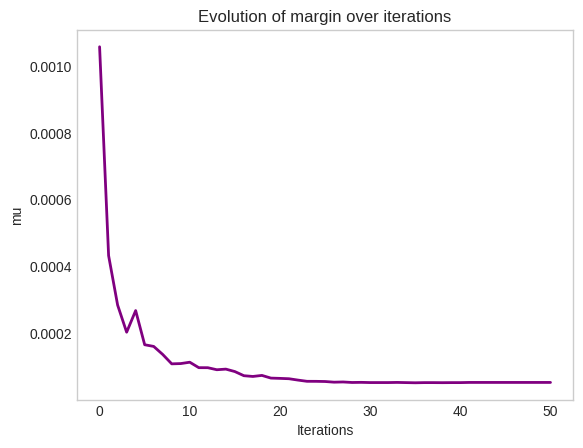

22:30:18 | INFO | ml_moo | Fit runtime: 3.70 seconds


In [14]:
method = 'mola'
scalarization = LogRegFairScalarization(X=X_train, y=y_train, fair_feat=fair_feature)
moopt = moo(scalarization).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

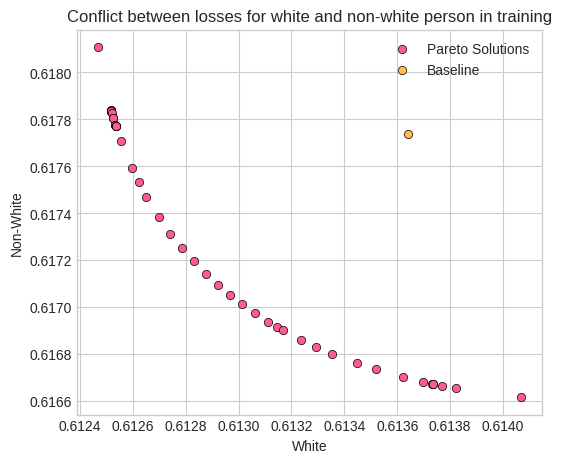

In [15]:
title="Conflict between losses for white and non-white person in training"
plot_pareto_2d(objectives=objs, 
               labels=("White", "Non-White"), 
               title=title,
               point = equal.objs,
               color="#FF5C8D"
               )

In [16]:
#method = 'mola'
#moopt = moo(w_scalar)
#moo_solutions[method] = moopt.mo_optimization(method, **opt_params)

22:30:18 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
22:30:18 | DEBUG | ml_moo | Finding 1th individual minimum


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return Variable._execution_engine.run_backward(  # Calls into t

new solution added [0.61283158 0.61719796]
new solution added [0.61351914 0.61673736]
new solution added [0.61314523 0.61691569]
new solution added [0.6124682  0.61810826]
solution dominated [0.61260705 0.6189783 ]


22:30:20 | DEBUG | ml_moo | Calculated weights: [0.71264979 0.28735021]
22:30:20 | DEBUG | ml_moo | Importance: 0.00026721523201611586
22:30:20 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61662356]
22:30:20 | DEBUG | ml_moo | Iteration 5
22:30:20 | DEBUG | ml_moo | Solutions list: [array([0.6124682 , 0.61810826]), array([0.61314523, 0.61691569]), array([0.61351914, 0.61673736]), array([0.61283158, 0.61719796]), array([0.61452791, 0.61662356])]
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_r

new solution added [0.61259662 0.61759129]
new solution added [0.61296642 0.61705222]
new solution added [0.61269772 0.61738368]


...

new solution added [0.61251841 0.61783419]
new solution added [0.61251841 0.6178342 ]


22:30:24 | DEBUG | ml_moo | Calculated weights: [0.79997174 0.20002826]
22:30:24 | DEBUG | ml_moo | Importance: 5.1895414690195096e-05
22:30:24 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61661664]
22:30:24 | DEBUG | ml_moo | Iteration 46
22:30:24 | DEBUG | ml_moo | Solutions list: [array([0.61251841, 0.6178342 ]), array([0.61251841, 0.61783419]), array([0.61251841, 0.61783419]), array([0.61251841, 0.6178342 ]), array([0.6125347 , 0.61777309]), array([0.6125338 , 0.61777628]), array([0.6125257, 0.6178059]), array([0.6125338 , 0.61777629]), array([0.61253477, 0.61777285]), array([0.61252574, 0.61780574]), array([0.61253469, 0.61777314]), array([0.61382386, 0.61665356]), array([0.61373409, 0.61667301]), array([0.61373418, 0.61667299]), array([0.613733  , 0.61667327]), array([0.61369671, 0.61668215]), array([0.61251985, 0.61782848]), array([0.61251676, 0.61784084]), array([0.6125348 , 0.61777276]), array([0.61316763, 0.61690087]), array([0.61262163, 0.61753202]), array([0.61

new solution added [0.61251841 0.6178342 ]
new solution added [0.61251841 0.6178342 ]
new solution added [0.61251841 0.6178342 ]


22:30:24 | DEBUG | ml_moo | Calculated weights: [0.79997061 0.20002939]
22:30:24 | DEBUG | ml_moo | Importance: 5.189286118034708e-05
22:30:24 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61661664]
22:30:24 | DEBUG | ml_moo | Iteration 49
22:30:24 | DEBUG | ml_moo | Solutions list: [array([0.61251841, 0.6178342 ]), array([0.61251841, 0.6178342 ]), array([0.61251841, 0.6178342 ]), array([0.61251841, 0.6178342 ]), array([0.61251841, 0.61783419]), array([0.61251841, 0.61783419]), array([0.61251841, 0.6178342 ]), array([0.6125347 , 0.61777309]), array([0.6125338 , 0.61777628]), array([0.6125257, 0.6178059]), array([0.6125338 , 0.61777629]), array([0.61253477, 0.61777285]), array([0.61252574, 0.61780574]), array([0.61253469, 0.61777314]), array([0.61382386, 0.61665356]), array([0.61373409, 0.61667301]), array([0.61373418, 0.61667299]), array([0.613733  , 0.61667327]), array([0.61369671, 0.61668215]), array([0.61251985, 0.61782848]), array([0.61251676, 0.61784084]), array([0.612

new solution added [0.61251841 0.6178342 ]
new solution added [0.61251841 0.6178342 ]


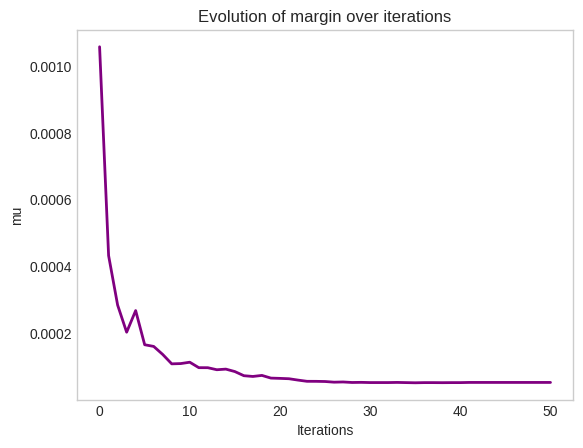

22:30:24 | INFO | ml_moo | Fit runtime: 6.22 seconds


In [17]:
method = 'mola'
scalarization = LogRegFairScalarization(X=X_train, y=y_train, fair_feat=fair_feature, gradient=True)
moopt = moo(scalarization).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

In [18]:
methods = [
    'mola', 
    'monise', 
    'random_weight'
    ]

## Comparison between MOO methods

In [19]:
from ml_moo.tests.experiments.run import run_experiments
from ml_moo.analysis.moo_analyzer import Analyzer

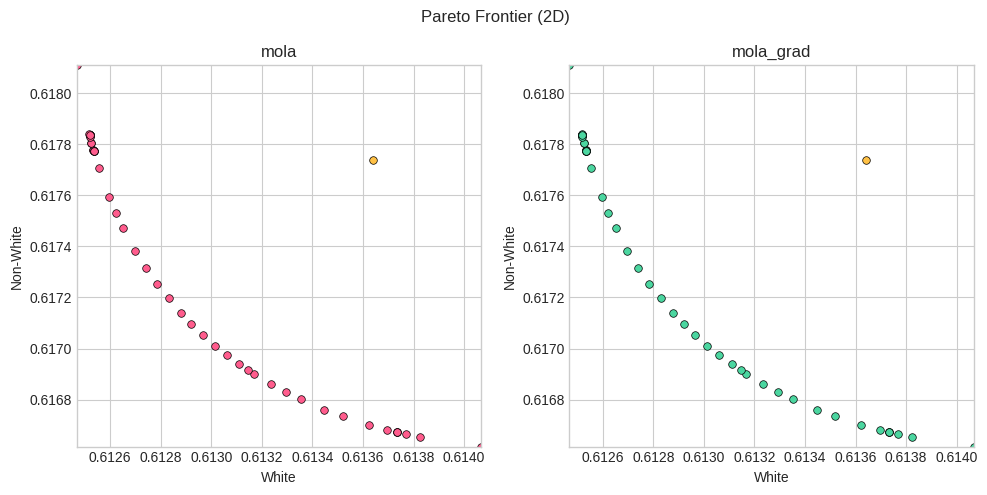

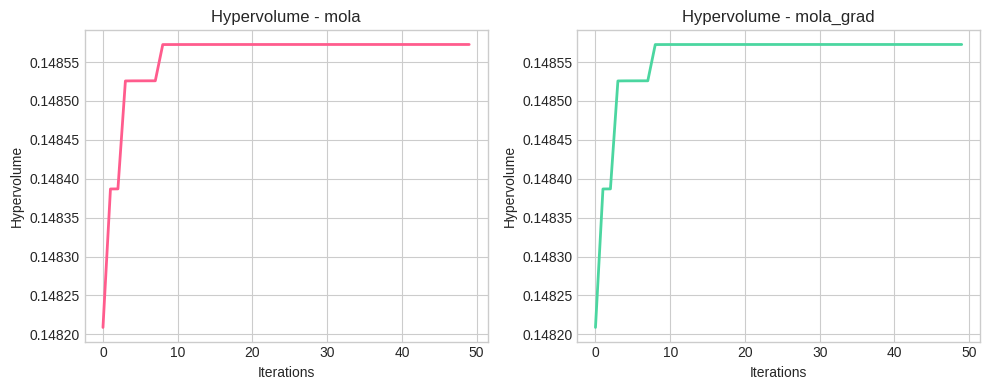

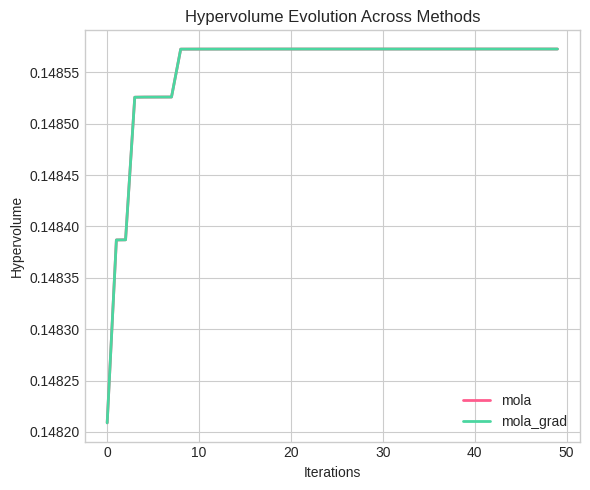

[Analyzer] Visualization complete.


In [20]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }
colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = ["White", "Non-White"]
Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      point = equal.objs,
                      axis_label=axis_label
                      )

22:30:25 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
22:30:25 | DEBUG | ml_moo | Finding 1th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:30:25 | DEBUG | ml_moo | Finding 2th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. O

Running MOLA...
new solution added [0.61283158 0.61719796]
new solution added [0.61351914 0.61673736]
new solution added [0.61311603 0.6169358 ]
new solution added [0.61246816 0.61810858]
solution dominated [0.61260705 0.6189783 ]


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:30:25 | DEBUG | ml_moo | Calculated weights: [0.71286622 0.28713378]
22:30:25 | DEBUG | ml_moo | Importance: 0.0002673163285796809
22:30:25 | DEBUG | ml_moo | Global lower bound (y*): [0.61246816 0.61662356]
22:30:25 | DEBUG | ml_moo | Iteration 5
22:30:25 | DEBUG | ml_moo | Solutions list: [array([0.61246816, 0.61810858]), array([0.61311603, 0.6169358 ]), array([0.61351914, 0.61673736]), array([0.61283158, 0.61719796]), array([0.61452791, 0.616623

new solution added [0.61259639 0.61759187]
new solution added [0.61269123 0.61739489]
new solution added [0.6129635 0.617055 ]


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:30:25 | DEBUG | ml_moo | Calculated weights: [0.10138701 0.89861299]
22:30:25 | DEBUG | ml_moo | Importance: 0.00010760407238430414
22:30:25 | DEBUG | ml_moo | Global lower bound (y*): [0.61246816 0.61662356]
22:30:25 | DEBUG | ml_moo | Iteration 9
22:30:25 | DEBUG | ml_moo | Solutions list: [array([0.61330731, 0.61682314]), array([0.6129635, 0.617055 ]), array([0.61269123, 0.61739489]), array([0.61259639, 0.61759187]), array([0.61246816, 0.6181085

...

new solution added [0.61373401 0.61667303]
new solution added [0.61376024 0.61666698]
new solution added [0.61372857 0.61667432]


22:30:28 | DEBUG | ml_moo | Calculated weights: [0.18409196 0.81590804]
22:30:28 | DEBUG | ml_moo | Importance: 5.1730885271907695e-05
22:30:28 | DEBUG | ml_moo | Global lower bound (y*): [0.61246816 0.61661664]
22:30:28 | DEBUG | ml_moo | Iteration 48
22:30:28 | DEBUG | ml_moo | Solutions list: [array([0.61372857, 0.61667432]), array([0.61376024, 0.61666698]), array([0.61373401, 0.61667303]), array([0.61376723, 0.61666542]), array([0.61373414, 0.61667299]), array([0.61373414, 0.61667299]), array([0.61373414, 0.61667299]), array([0.61375311, 0.6166686 ]), array([0.61373414, 0.61667299]), array([0.61373414, 0.61667299]), array([0.6137341, 0.616673 ]), array([0.61373422, 0.61667298]), array([0.61373116, 0.6166737 ]), array([0.61373302, 0.61667327]), array([0.61314051, 0.61691821]), array([0.61369675, 0.61668215]), array([0.61280403, 0.61722658]), array([0.61251284, 0.61785702]), array([0.61252608, 0.61780447]), array([0.61308844, 0.61695394]), array([0.61253688, 0.61776547]), array([0.61

new solution added [0.6137579  0.61666751]
new solution added [0.61375829 0.61666742]


22:30:29 | DEBUG | ml_moo | Calculated weights: [0.1834832 0.8165168]
22:30:29 | DEBUG | ml_moo | Importance: 5.205354190851441e-05
22:30:29 | DEBUG | ml_moo | Global lower bound (y*): [0.61246816 0.61661664]


new solution added [0.61373401 0.61667303]


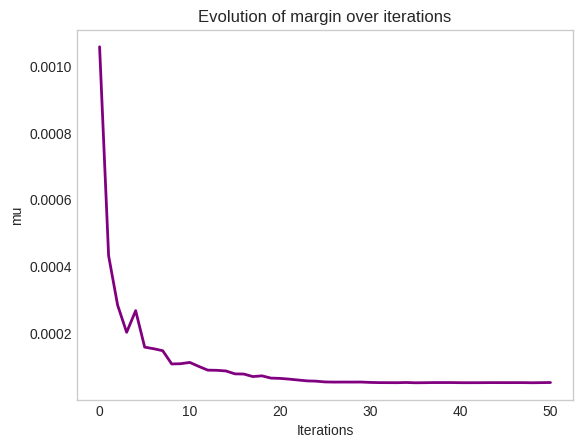

22:30:29 | INFO | ml_moo | Fit runtime: 3.94 seconds
22:30:29 | DEBUG | ml_moo | Filtered parameters for monise: {'nodeTimeLimit': 2, 'targetSize': 50, 'targetGap': 0, 'nodeGap': 0.05, 'norm': False}
22:30:29 | DEBUG | ml_moo.moo.monise | Finding 1th individual minima
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:30:29 | DEBUG | ml_moo.moo.monise | Finding 2th individual minima
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: Conv

Running MONISE...
monise


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:30:29 | DEBUG | ml_moo.moo.monise | 3th solution - importance: 1.0
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the docum

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:30:29 | DEBUG | ml_moo.moo.monise | 11th solution - importance: 0.06403042276867342
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also r

...

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:30:33 | DEBUG | ml_moo.moo.monise | 48th solution - importance: 0.0018732009450139013
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:30:33 | DEBUG | ml_moo.moo.monise | 50th solution - importance: 0.0018732009450139013
22:30:33 | WARNING | ml_moo | Ignored parameters for random_weights: {'nodeTimeLimit', 'targetGap', 'nodeGap'}
22:30:33 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 50, 'norm': False}
22:30:33 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sk

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Running RANDOM_WEIGHT...


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:30:33 | DEBUG | ml_moo.moo.random_weights | 3th solution
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation f

In [21]:
experiment_results, pareto_dict, hypervolumes_dict = run_experiments(
                                                            methods = methods,
                                                            opt_params = opt_params,
                                                            model = reg,
                                                            train_fn = train_fn_logreg,
                                                            num_objs = num_objs,
                                                            mola_hv = False
                                                            )

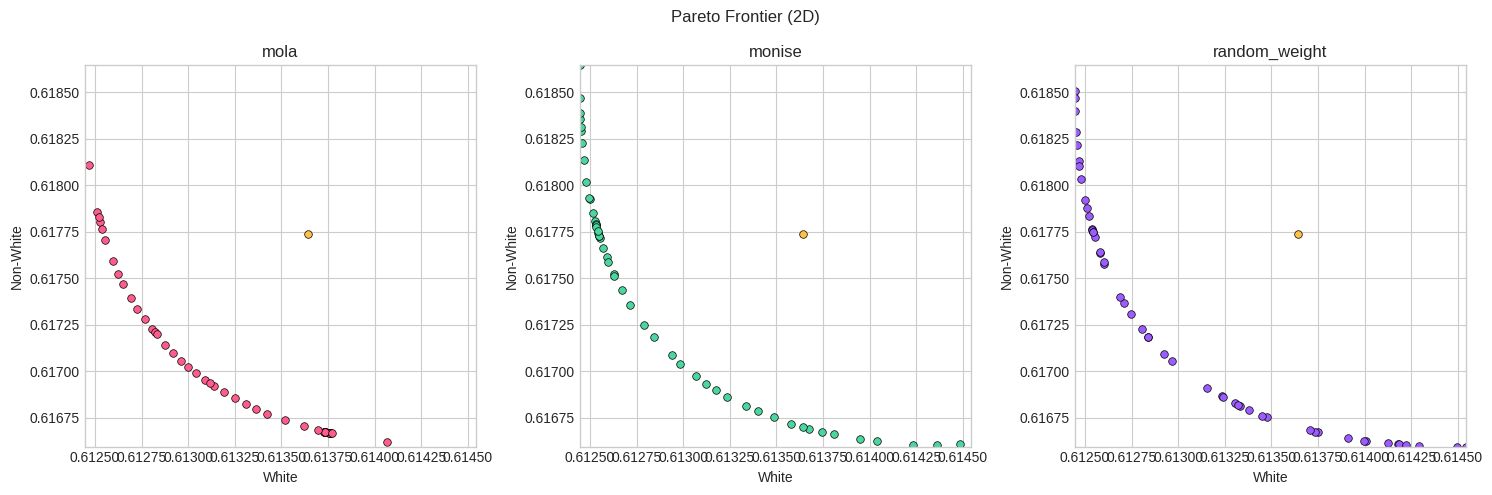

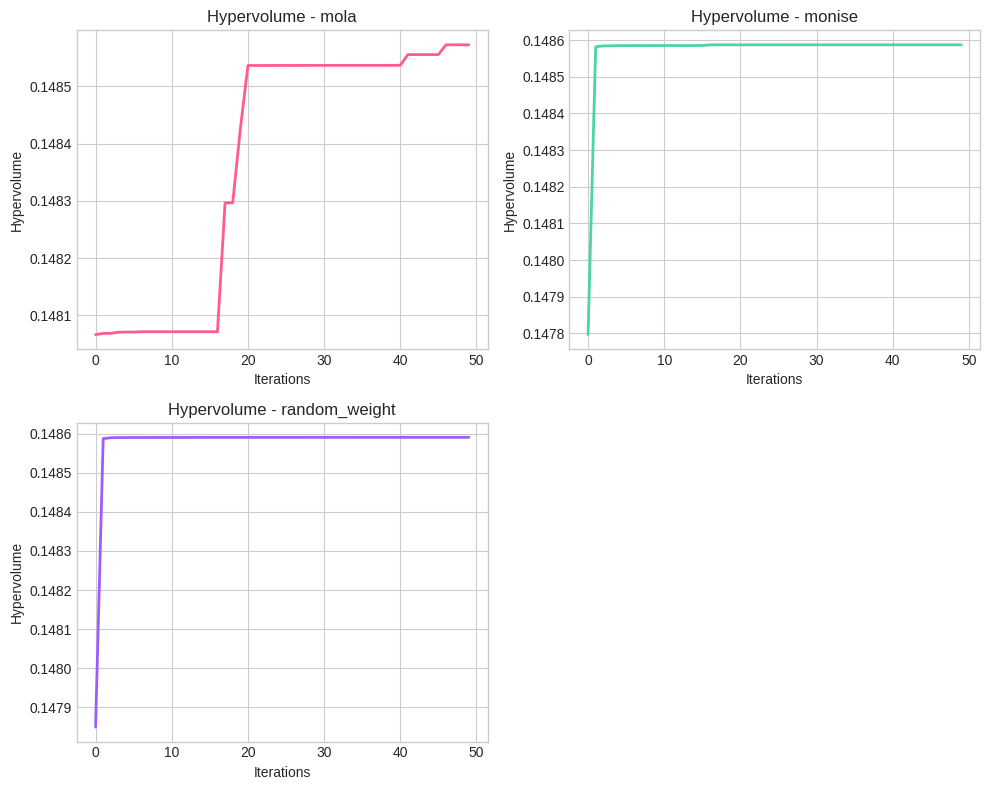

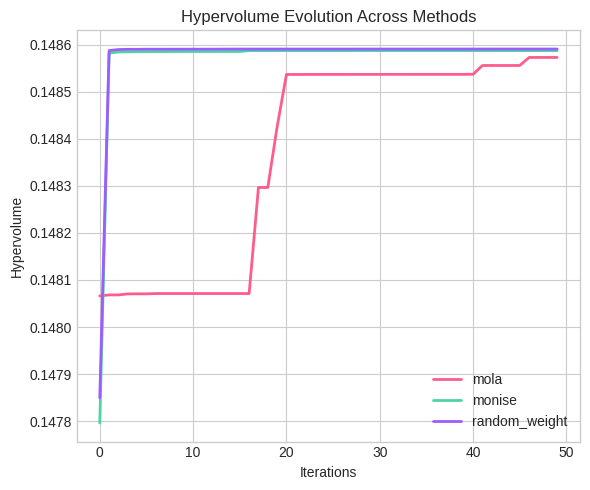

[Analyzer] Visualization complete.


In [22]:
# pareto_dict = {
#         method: res["objectives"]
#         for method, res in results.items()
#         if "objectives" in res
#     }
# 
# hypervolumes_dict = {
#         method: res["hypervolume"]
#         for method, res in results.items()
#         if "hypervolume" in res
#     }
colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = ["White", "Non-White"]
Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      point = equal.objs,
                      axis_label=axis_label
                      )